In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import anderson_ksamp
import mlflow
import torch
from torch import nn, optim
import torch.utils.data as data_utils
from IPython.display import clear_output
from pytorch_lightning import Trainer
from pytorch_lightning.utilities.seed import seed_everything
from pytorch_lightning.callbacks import Callback
import yaml

from genhack.dataset import StationsDataset
from genhack.models import models
from genhack.utils import *
from train import train

In [50]:
df_all = pd.read_csv('data/df_all.csv')
df_all['dates'] = pd.to_datetime(df_all['dates'])
df_all = df_all.set_index('dates').sort_index()

df_train = pd.read_csv('data/df_train.csv')
df_train['dates'] = pd.to_datetime(df_train['dates'])
df_train = df_train.set_index('dates').sort_index()

df_test = pd.read_csv('data/df_test.csv')
df_test['dates'] = pd.to_datetime(df_test['dates'])
df_test = df_test.set_index('dates').sort_index()

# Intrayear dependencies

<AxesSubplot:xlabel='dates', ylabel='s4'>

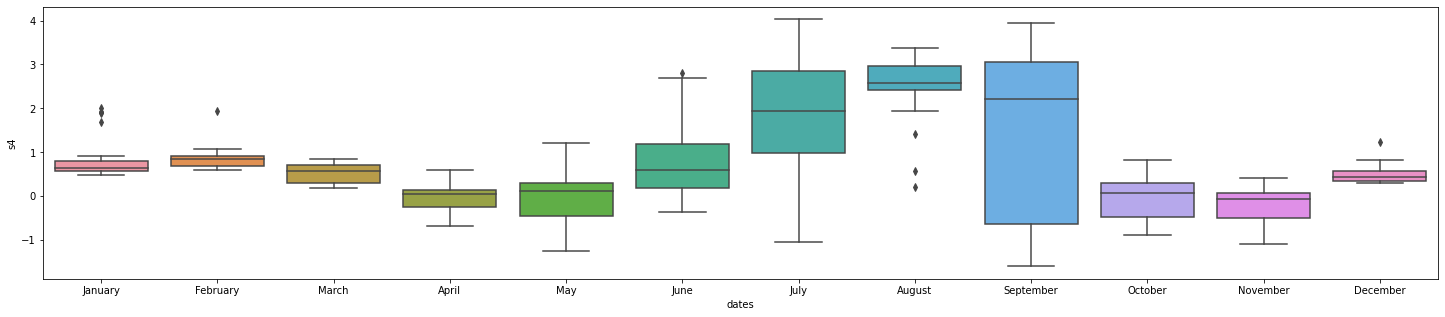

In [233]:
year = 2006
station = 's4'

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all[df_all.index.year == year]
sns.boxplot(y=df_plot[station], x=df_plot.index.month_name(), ax=ax)

# Dependencies over years

<AxesSubplot:xlabel='dates'>

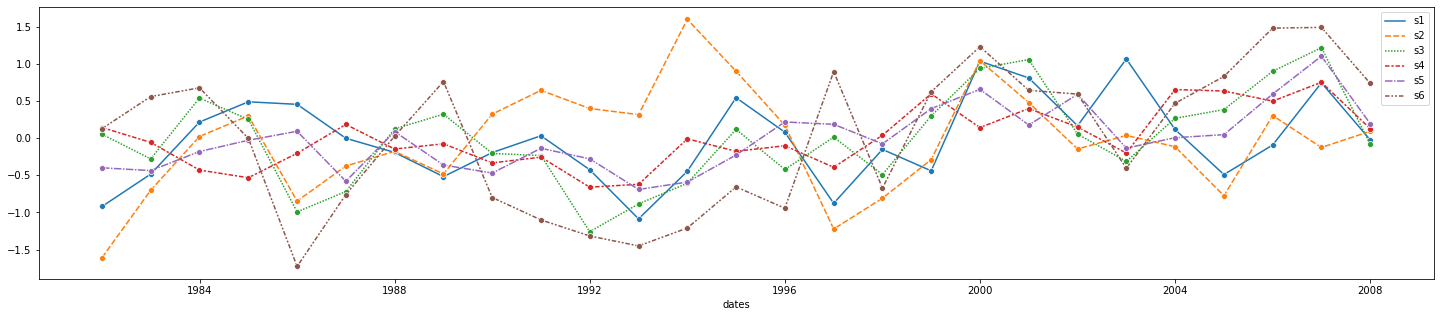

In [226]:
fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all.resample('Y').mean()
sns.lineplot(data=df_plot, ax=ax, marker='o')

<AxesSubplot:xlabel='dates', ylabel='s1'>

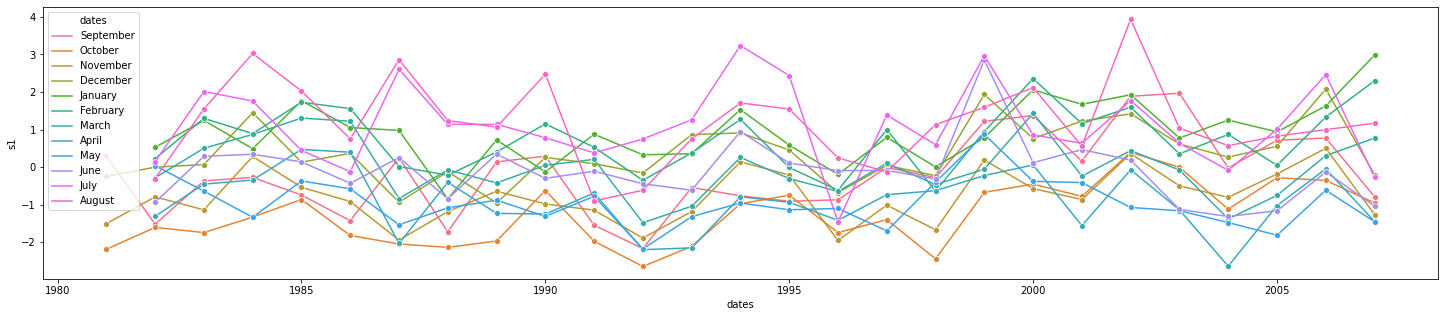

In [222]:
fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all.resample('M').mean()
sns.lineplot(data=df_plot, x=df_plot.index.year, y='s1', hue=df_plot.index.month_name(), ax=ax, marker='o')

<AxesSubplot:title={'center':'s1'}, xlabel='dates', ylabel='s1'>

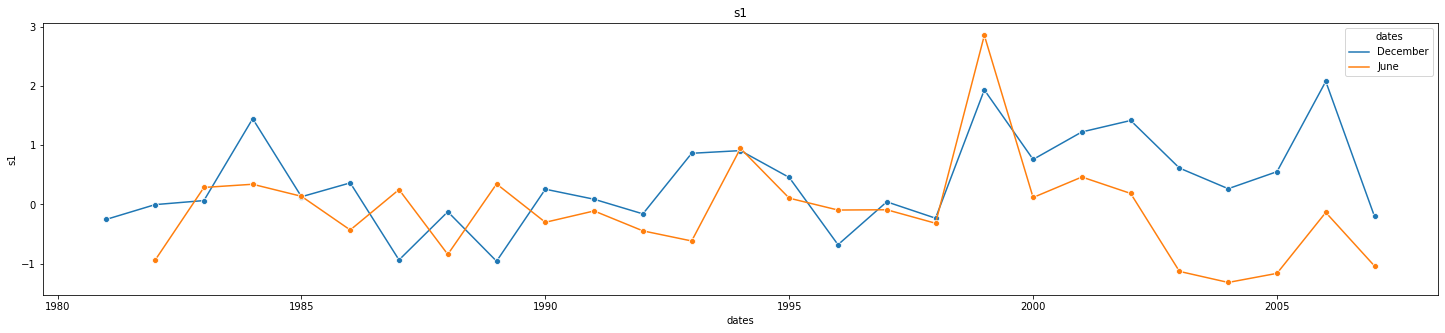

In [303]:
fig, ax = plt.subplots(figsize=(25, 5))
station = 's1'

ax.set_title(station)
df_plot = df_all.resample('M').mean()
df_plot = df_plot[df_plot.index.month.isin([6, 12])]
sns.lineplot(data=df_plot, x=df_plot.index.year, y=station, hue=df_plot.index.month_name(), ax=ax, marker='o')

<AxesSubplot:xlabel='dates', ylabel='s3'>

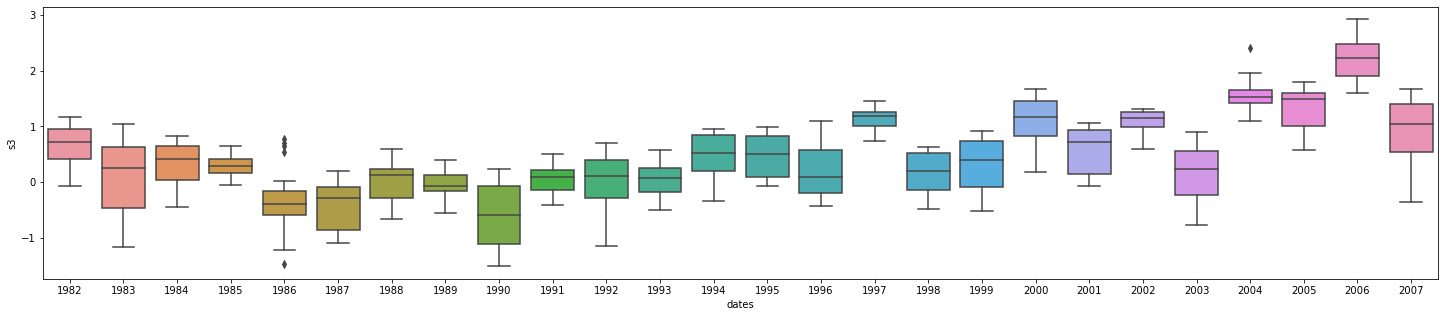

In [307]:
station = 's3'
month = 1

fig, ax = plt.subplots(figsize=(25, 5))
df_plot = df_all[df_all.index.month == month]
sns.boxplot(y=df_plot[station], x=df_plot.index.year, ax=ax)

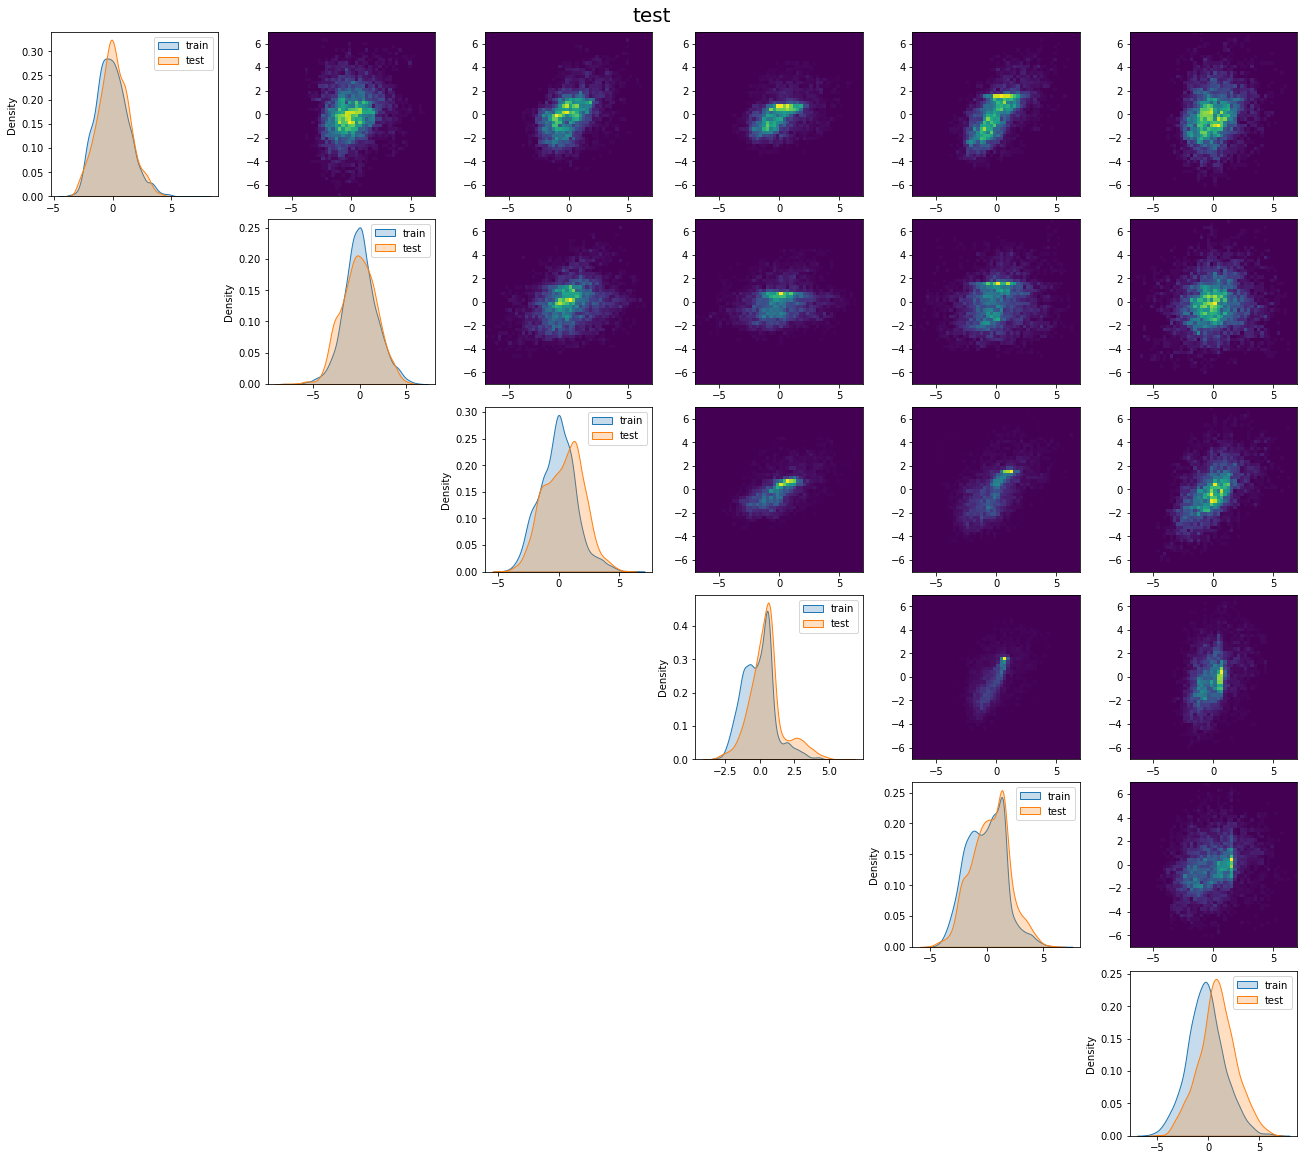

In [236]:
fig, ax = plt.subplots(nrows=6, ncols=6, figsize=(18, 16), constrained_layout=True)
fig.suptitle('test', fontsize=20)

for i in range(6):
    for j in range(6):
        if i < j:
            ax[i][j].hist2d(df_train[f's{i+1}'], df_train[f's{j+1}'], bins=50, range=[[-7, 7], [-7, 7]])
        if i > j:
            fig.delaxes(ax[i][j])
    sns.kdeplot(data=df_train.to_numpy()[:, i], ax=ax[i][i], fill=True, label='train')
    sns.kdeplot(data=df_test.to_numpy()[:, i], ax=ax[i][i], fill=True, label='test')
    ax[i][i].legend()
